In [3]:
!unzip aggregated.zip

Archive:  aggregated.zip
replace sp26cai6108mle-project-aggregated/aggregated/backpack/img1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
!mv sp26cai6108mle-project-aggregated mle-aggregated

In [5]:
LABEL_ORDER = [
    "pen", "paper", "book", "clock", "phone", "laptop",
    "chair", "desk", "bottle", "keychain", "backpack", "calculator"
]

In [6]:
import torch

LABEL_TO_IDX = {label: i for i, label in enumerate(LABEL_ORDER)}

def folder_to_multihot(folder_name):
    labels = folder_name.split("_")
    target = torch.zeros(len(LABEL_ORDER), dtype=torch.float32)

    for label in labels:
        target[LABEL_TO_IDX[label]] = 1.0

    return target

In [7]:
from torchvision import transforms
# they all should be [128, 128] anyways
train_transforms = transforms.Compose([
    transforms.ToTensor(),  # convert PIL image to PyTorch tensor and scale pixels to [0, 1]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet RGB channel means
        std=[0.229, 0.224, 0.225]    # ImageNet RGB channel standard deviations
    )
])

# transforms.RandomHorizontalFlip(),
# transforms.RandomRotation(10),
# eventually apply above for data augmentation

val_transforms = transforms.Compose([
    transforms.ToTensor(),  # convert PIL image to PyTorch tensor and scale pixels to [0, 1]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet RGB channel means
        std=[0.229, 0.224, 0.225]    # ImageNet RGB channel standard deviations
    )
])

In [8]:
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset

LABEL_ORDER = [
    "pen", "paper", "book", "clock", "phone", "laptop",
    "chair", "desk", "bottle", "keychain", "backpack", "calculator"
]
LABEL_TO_IDX = {label: i for i, label in enumerate(LABEL_ORDER)}
VALID_LABELS = set(LABEL_ORDER)

class MultiLabelFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for folder in self.root_dir.iterdir():
            if not folder.is_dir():
                continue

            labels = folder.name.split("_")

            # skip invalid folders
            if any(label not in VALID_LABELS for label in labels):
                continue
            if len(labels) != len(set(labels)):
                continue

            target = torch.zeros(len(LABEL_ORDER), dtype=torch.float32)
            for label in labels:
                target[LABEL_TO_IDX[label]] = 1.0

            for img_path in folder.glob("*.png"):
                self.samples.append((img_path, target.clone()))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, target = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, target

In [9]:
!ls

aggregated.zip	mle-aggregated	sample_data


In [10]:
data_root = "/content/mle-aggregated/aggregated"

dataset = MultiLabelFolderDataset(data_root, transform=train_transforms)

print("Number of samples:", len(dataset))

img, target = dataset[0]
print("Image shape:", img.shape)
print("Target shape:", target.shape)
print("Target:", target)

Number of samples: 4543
Image shape: torch.Size([3, 128, 128])
Target shape: torch.Size([12])
Target: tensor([1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1.])


In [11]:
img, target = dataset[0]
print(img.shape)      # should look like [3, 128, 128]
print(target.shape)   # should look like [12]
print(target)

torch.Size([3, 128, 128])
torch.Size([12])
tensor([1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1.])


In [12]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [14]:
images, labels = next(iter(train_loader))
print(images.shape)   # [batch_size, 3, 224, 224]
print(labels.shape)   # [batch_size, 12]

torch.Size([32, 3, 128, 128])
torch.Size([32, 12])


In [15]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 12)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


In [16]:
criterion = nn.BCEWithLogitsLoss()

In [17]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float()   # important for BCEWithLogitsLoss

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            correct += (preds == labels).sum().item()
            total += labels.numel()

    print(
        f"Epoch {epoch+1}, "
        f"Train Loss: {train_loss/len(train_loader):.4f}, "
        f"Val Loss: {val_loss/len(val_loader):.4f}, "
        f"Val Label Acc: {correct/total:.4f}"
    )

Epoch 1, Train Loss: 0.3068, Val Loss: 0.2989, Val Label Acc: 0.8868
Epoch 2, Train Loss: 0.2217, Val Loss: 0.2694, Val Label Acc: 0.9039
Epoch 3, Train Loss: 0.1714, Val Loss: 0.2984, Val Label Acc: 0.8903
Epoch 4, Train Loss: 0.1328, Val Loss: 0.2857, Val Label Acc: 0.9074
Epoch 5, Train Loss: 0.0919, Val Loss: 0.2807, Val Label Acc: 0.9124
Epoch 6, Train Loss: 0.0674, Val Loss: 0.3559, Val Label Acc: 0.8983
Epoch 7, Train Loss: 0.0555, Val Loss: 0.2878, Val Label Acc: 0.9148
Epoch 8, Train Loss: 0.0380, Val Loss: 0.3061, Val Label Acc: 0.9147
Epoch 9, Train Loss: 0.0262, Val Loss: 0.2965, Val Label Acc: 0.9187
Epoch 10, Train Loss: 0.0224, Val Loss: 0.3258, Val Label Acc: 0.9099
Epoch 11, Train Loss: 0.0247, Val Loss: 0.3648, Val Label Acc: 0.9116
Epoch 12, Train Loss: 0.0312, Val Loss: 0.3852, Val Label Acc: 0.9043
Epoch 13, Train Loss: 0.0317, Val Loss: 0.3625, Val Label Acc: 0.9062
Epoch 14, Train Loss: 0.0277, Val Loss: 0.3480, Val Label Acc: 0.9174
Epoch 15, Train Loss: 0.0202,

KeyboardInterrupt: 

Epoch 1, Train Loss: 0.0320, Val Loss: 0.3860, Micro F1: 0.6798, Macro F1: 0.6768
Epoch 2, Train Loss: 0.0185, Val Loss: 0.3872, Micro F1: 0.6908, Macro F1: 0.6832
Epoch 3, Train Loss: 0.0131, Val Loss: 0.3881, Micro F1: 0.6840, Macro F1: 0.6785
Epoch 4, Train Loss: 0.0097, Val Loss: 0.3730, Micro F1: 0.6941, Macro F1: 0.6883
Epoch 5, Train Loss: 0.0119, Val Loss: 0.4476, Micro F1: 0.6744, Macro F1: 0.6720
Epoch 6, Train Loss: 0.0165, Val Loss: 0.4749, Micro F1: 0.6302, Macro F1: 0.6295
Epoch 7, Train Loss: 0.0247, Val Loss: 0.5031, Micro F1: 0.6530, Macro F1: 0.6473
Epoch 8, Train Loss: 0.0242, Val Loss: 0.4426, Micro F1: 0.6626, Macro F1: 0.6555
Epoch 9, Train Loss: 0.0161, Val Loss: 0.3999, Micro F1: 0.7010, Macro F1: 0.6967
Epoch 10, Train Loss: 0.0120, Val Loss: 0.4027, Micro F1: 0.6899, Macro F1: 0.6858
Epoch 11, Train Loss: 0.0076, Val Loss: 0.3699, Micro F1: 0.7115, Macro F1: 0.7099
Epoch 12, Train Loss: 0.0043, Val Loss: 0.3804, Micro F1: 0.7046, Macro F1: 0.7024
Epoch 13, Tra

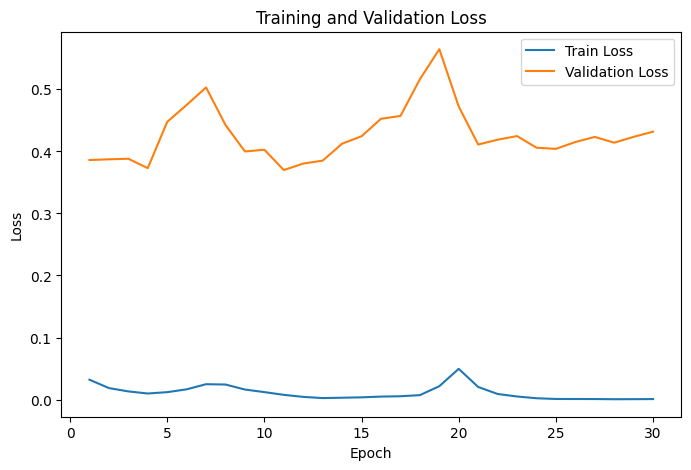

In [18]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 30

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_labels.append(labels.cpu().int())
            all_preds.append(preds.cpu())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()

    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    print(
        f"Epoch {epoch+1}, "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}, "
        f"Micro F1: {micro_f1:.4f}, "
        f"Macro F1: {macro_f1:.4f}"
    )

# plot after training
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [19]:
with torch.no_grad():
    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()

In [20]:
torch.save(model.state_dict(), "resnet_mle.pth")

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

for i, name in enumerate(LABEL_ORDER):
    print(
        f"{name:12s} | "
        f"Precision: {per_class_precision[i]:.4f} | "
        f"Recall: {per_class_recall[i]:.4f} | "
        f"F1: {per_class_f1[i]:.4f}"
    )

pen          | Precision: 0.8889 | Recall: 0.5070 | F1: 0.6457
paper        | Precision: 0.7540 | Recall: 0.7252 | F1: 0.7393
book         | Precision: 0.7477 | Recall: 0.5646 | F1: 0.6434
clock        | Precision: 0.7500 | Recall: 0.4898 | F1: 0.5926
phone        | Precision: 0.8105 | Recall: 0.5203 | F1: 0.6337
laptop       | Precision: 0.8615 | Recall: 0.7089 | F1: 0.7778
chair        | Precision: 0.7900 | Recall: 0.6077 | F1: 0.6870
desk         | Precision: 0.7589 | Recall: 0.6855 | F1: 0.7203
bottle       | Precision: 0.7551 | Recall: 0.5248 | F1: 0.6192
keychain     | Precision: 0.8228 | Recall: 0.5508 | F1: 0.6599
backpack     | Precision: 0.8522 | Recall: 0.7206 | F1: 0.7809
calculator   | Precision: 0.9388 | Recall: 0.7419 | F1: 0.8288


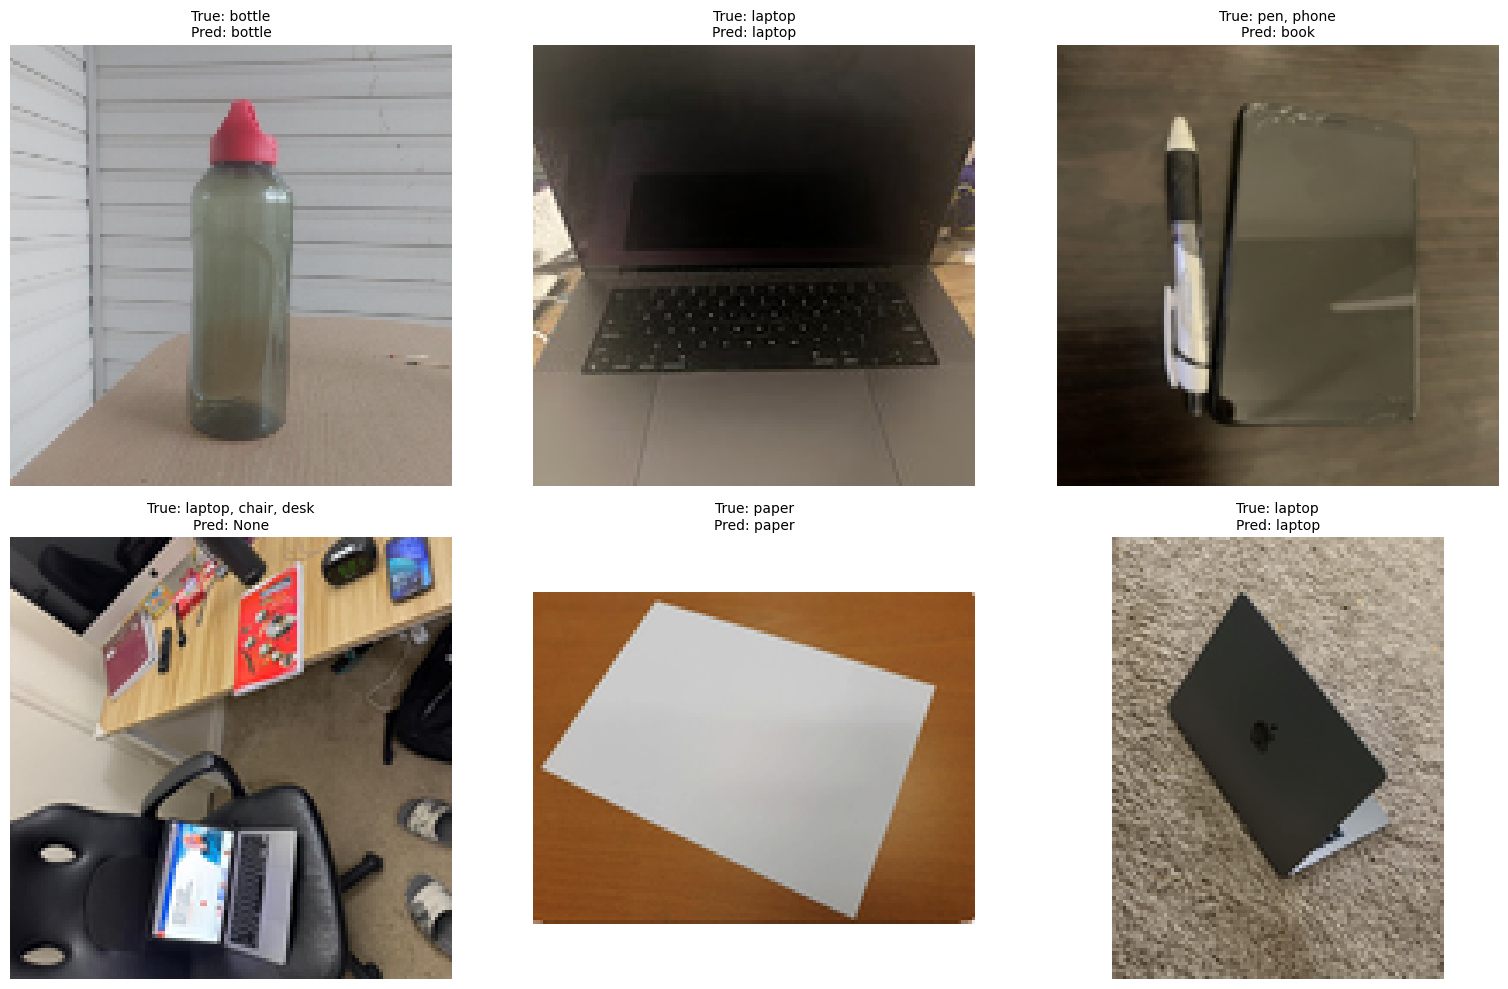

In [23]:
import torch
import matplotlib.pyplot as plt

class_names = [
    "pen", "paper", "book", "clock", "phone", "laptop",
    "chair", "desk", "bottle", "keychain", "backpack", "calculator"
]

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

model.eval()

images, labels = next(iter(val_loader))
images = images.to(device)
labels = labels.to(device).float()

with torch.no_grad():
    outputs = model(images)
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).int()

images = images.cpu()
labels = labels.cpu().int()
preds = preds.cpu()
probs = probs.cpu()

num_examples = 6
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, ax in enumerate(axes.flat[:num_examples]):
    img = images[i]

    # unnormalize
    img = img * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = img.clip(0, 1)

    ax.imshow(img)
    ax.axis("off")

    true_labels = [class_names[j] for j in range(len(class_names)) if labels[i][j] == 1]
    pred_labels = [class_names[j] for j in range(len(class_names)) if preds[i][j] == 1]

    ax.set_title(
        f"True: {', '.join(true_labels) if true_labels else 'None'}\n"
        f"Pred: {', '.join(pred_labels) if pred_labels else 'None'}",
        fontsize=10
    )

plt.tight_layout()
plt.show()